# Prueba de uso de $PCA$

## **Qué es PCA**

El **PCA** (*Principal Component Analysis*), o **Análisis de Componentes Principales**, es una técnica estadística utilizada para transformar un conjunto de variables originales en un nuevo conjunto de variables llamadas **componentes principales**.

Estas componentes principales son combinaciones lineales de las variables originales. Es decir, cada componente se construye mezclando las variables iniciales con ciertos pesos calculados matemáticamente.

Por ejemplo, si se tienen variables originales como:

$$
X_1, X_2, X_3, X_4
$$

PCA puede transformarlas en nuevas variables:

$$
PC_1, PC_2, PC_3, PC_4
$$

donde cada componente tiene la forma:

$$
PC_1 = a_1X_1 + a_2X_2 + a_3X_3 + a_4X_4
$$

La primera componente principal, $PC_1$, captura la mayor cantidad posible de variabilidad de los datos. La segunda componente, $PC_2$, captura la mayor variabilidad restante, pero siendo independiente u ortogonal respecto a la primera. Este proceso continúa con las demás componentes.

La idea principal del PCA es **resumir la información de muchas variables en menos componentes**, conservando la mayor cantidad posible de información importante.

---

## **Para qué sirve y cuándo conviene usarlo**

PCA sirve principalmente para **reducir la dimensionalidad** de un conjunto de datos. Esto significa disminuir el número de variables con las que se trabaja, pero tratando de conservar la mayor parte de la información original.

Por ejemplo, si un dataset tiene 30 variables numéricas, PCA puede reducirlas a 5, 6 o 10 componentes principales, dependiendo de cuánta varianza se quiera conservar.

Una forma común de usarlo es indicar un porcentaje de varianza explicada:

```python
PCA(n_components=0.95)
```

Esto significa que PCA seleccionará automáticamente el menor número de componentes principales necesarios para conservar al menos el **95% de la varianza total** de los datos.

PCA es especialmente conveniente cuando se trabaja con muchas variables numéricas que presentan correlación entre sí, ya que permite resumir información redundante en un menor número de componentes.

Por ejemplo, en un dataset médico pueden existir variables como radio, perímetro y área de un tumor. Estas variables suelen estar altamente correlacionadas porque todas describen características de tamaño. En ese caso, PCA puede resumir esa información en menos componentes.

También es útil cuando existe **multicolinealidad**, es decir, cuando varias variables independientes están fuertemente correlacionadas entre sí. Esto puede afectar modelos como regresión lineal o regresión logística, ya que las variables explicativas contienen información repetida.

PCA ayuda porque las componentes principales resultantes son **ortogonales entre sí**, es decir, no están correlacionadas. Esto elimina la correlación lineal entre las nuevas variables generadas.

Otro uso importante del PCA es la **visualización de datos**. Cuando se tienen muchas variables, no es posible graficarlas directamente. Sin embargo, PCA permite reducir los datos a dos o tres componentes principales y representarlos en una gráfica 2D o 3D. Esto ayuda a observar patrones, grupos, separación entre clases o posibles datos atípicos.

PCA suele ser más conveniente antes de aplicar modelos sensibles a la dimensionalidad o a la escala, como:

- KNN
- SVM
- Regresión lineal
- Regresión logística
- Clustering
- Redes neuronales simples

En estos modelos, reducir el número de variables puede ayudar a mejorar el rendimiento, disminuir ruido y simplificar el entrenamiento.

Sin embargo, PCA no siempre conviene. En modelos basados en árboles, como **Random Forest**, **XGBoost**, **LightGBM** o **CatBoost**, su uso no siempre mejora el desempeño, porque estos modelos ya manejan bastante bien variables correlacionadas y relaciones no lineales.

Además, al aplicar PCA se pierde interpretabilidad, ya que el modelo deja de trabajar con las variables originales y empieza a trabajar con componentes como $PC_1$, $PC_2$, etc.

Por ejemplo, sin PCA se podría decir:

> La variable `worst area` fue importante para clasificar el tumor.

Pero con PCA se diría:

> La componente `PC1` fue importante para clasificar el tumor.

Esto es menos claro, porque una componente principal puede estar formada por muchas variables originales al mismo tiempo.

Por esta razón, en modelos como Random Forest o XGBoost, PCA debe usarse solo si se busca reducir dimensionalidad o ruido, pero no necesariamente para mejorar el rendimiento predictivo.

En resumen, PCA conviene cuando:

- Hay muchas variables numéricas.
- Las variables están muy correlacionadas.
- Se quiere reducir dimensionalidad.
- Se quiere visualizar información compleja en 2D o 3D.
- Se quiere disminuir ruido.
- Se usan modelos sensibles a la dimensionalidad, como SVM, KNN o regresión.

No conviene tanto cuando:

- Se necesitan interpretar directamente las variables originales.
- Se tienen pocas variables.
- Se usan modelos basados en árboles.
- Las variables no están correlacionadas.
- La reducción de dimensionalidad no mejora el modelo.

---

## **Qué hace matemáticamente**

Matemáticamente, PCA busca nuevas direcciones en los datos donde exista la mayor variabilidad posible. Estas nuevas direcciones son los **componentes principales**.

El proceso parte de una matriz de datos:

$$
X =
\begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1p} \\
x_{21} & x_{22} & \cdots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
$$

donde:

- $n$ representa el número de observaciones.
- $p$ representa el número de variables.

Antes de aplicar PCA, normalmente se centran o estandarizan los datos. Si las variables tienen diferentes escalas, se utiliza la estandarización:

$$
Z_j = \frac{X_j - \mu_j}{\sigma_j}
$$

donde:

- $X_j$ es la variable original.
- $\mu_j$ es la media de la variable.
- $\sigma_j$ es la desviación estándar de la variable.
- $Z_j$ es la variable estandarizada.

Esto hace que las variables tengan media 0 y desviación estándar 1. Este paso es importante porque PCA depende de la varianza, y una variable con escala más grande podría dominar el resultado.

Después se calcula la matriz de covarianza:

$$
S = \frac{1}{n-1}Z^T Z
$$

Esta matriz resume cómo se relacionan las variables entre sí. En la diagonal aparecen las varianzas de cada variable, mientras que fuera de la diagonal aparecen las covarianzas entre pares de variables.

Luego PCA resuelve el problema de valores propios y vectores propios:

$$
Sv = \lambda v
$$

donde:

- $S$ es la matriz de covarianza.
- $v$ es un vector propio.
- $\lambda$ es un valor propio.

Los **vectores propios** indican las nuevas direcciones de los datos, es decir, las direcciones de los componentes principales. Los **valores propios** indican cuánta varianza hay en cada una de esas direcciones.

Los valores propios se ordenan de mayor a menor:

$$
\lambda_1 \geq \lambda_2 \geq \lambda_3 \geq \cdots \geq \lambda_p
$$

El vector propio asociado al valor propio más grande forma la primera componente principal. Por eso, la primera componente es la dirección donde los datos tienen mayor variabilidad.

La primera componente se calcula como:

$$
PC_1 = Zv_1
$$

La segunda componente se calcula como:

$$
PC_2 = Zv_2
$$

y así sucesivamente.

Cada componente principal es una proyección de los datos originales sobre una nueva dirección. Además, las componentes son ortogonales entre sí, por lo que no están correlacionadas.

La varianza explicada por cada componente se calcula como:

$$
\frac{\lambda_i}{\lambda_1 + \lambda_2 + \cdots + \lambda_p}
$$

Esto permite saber qué porcentaje de información conserva cada componente.

Por ejemplo, si los valores propios fueran:

$$
\lambda_1 = 5, \quad \lambda_2 = 3, \quad \lambda_3 = 1, \quad \lambda_4 = 1
$$

la varianza total sería:

$$
5 + 3 + 1 + 1 = 10
$$

Entonces, la primera componente explicaría:

$$
\frac{5}{10} = 0.50 = 50\%
$$

y la segunda componente explicaría:

$$
\frac{3}{10} = 0.30 = 30\%
$$

Entre las dos primeras componentes se conservaría:

$$
50\% + 30\% = 80\%
$$

Finalmente, si se eligen $k$ componentes, se forma una matriz $W$ con los primeros $k$ vectores propios:

$$
W =
\begin{bmatrix}
| & | & & | \\
v_1 & v_2 & \cdots & v_k \\
| & | & & |
\end{bmatrix}
$$

La transformación final se obtiene con:

$$
X_{PCA} = ZW
$$

donde:

- $Z$ son los datos estandarizados.
- $W$ contiene los vectores propios seleccionados.
- $X_{PCA}$ son los datos transformados a componentes principales.

Si originalmente se tenía una matriz con 30 variables:

$$
X \in \mathbb{R}^{n \times 30}
$$

y se seleccionan 6 componentes principales:

$$
X_{PCA} \in \mathbb{R}^{n \times 6}
$$

Entonces PCA redujo el número de variables de 30 a 6, conservando la mayor cantidad posible de varianza.

En términos geométricos, PCA puede entenderse como una rotación del sistema de ejes. Los ejes originales eran las variables $X_1, X_2, ..., X_p$, pero PCA construye nuevos ejes $PC_1, PC_2, ..., PC_p$, ordenados según la cantidad de información que explican.

## **Código**

Librerías

In [335]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.model_selection import RepeatedStratifiedKFold
import seaborn as sns

Carga del dataset

In [336]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

In [337]:
columnas = cancer.feature_names
nombre_de_clases = cancer.target_names

In [338]:
df = pd.DataFrame(
    data=X,
    columns=columnas
)

df['clase'] = y

In [339]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,clase
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Matriz de correlación

In [340]:
corr = df.corr()

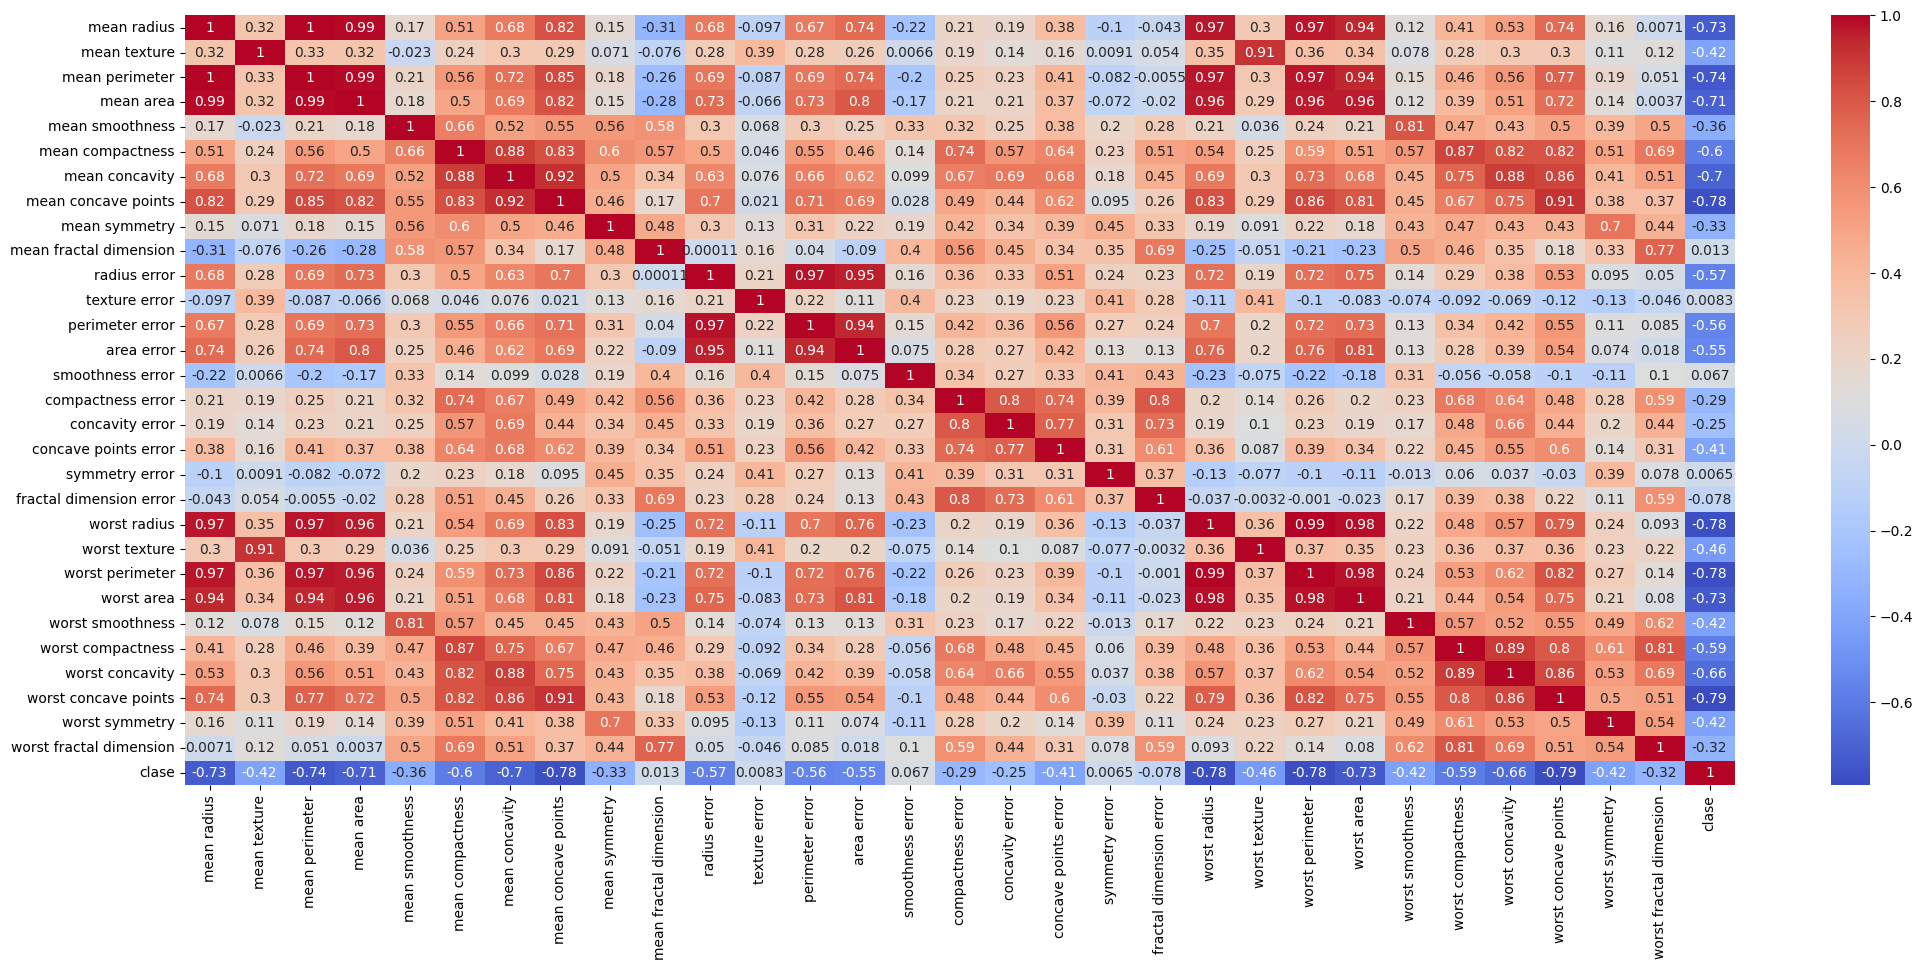

In [341]:
plt.figure(figsize=(25, 10))

sns.heatmap(
    corr, 
    annot=True, 
    cmap='coolwarm'
)

plt.show()

In [342]:
corr_matrix = corr.abs()

# Tomar solo la parte superior de la matriz
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Pares con correlación mayor a 0.90
high_corr = [
    (column, index, upper.loc[index, column])
    for column in upper.columns
    for index in upper.index
    if upper.loc[index, column] > 0.90
]

high_corr[:10]

[('mean perimeter', 'mean radius', np.float64(0.9978552814938109)),
 ('mean area', 'mean radius', np.float64(0.9873571700566127)),
 ('mean area', 'mean perimeter', np.float64(0.9865068039913907)),
 ('mean concave points', 'mean concavity', np.float64(0.9213910263788588)),
 ('perimeter error', 'radius error', np.float64(0.9727936770160764)),
 ('area error', 'radius error', np.float64(0.951830112110991)),
 ('area error', 'perimeter error', np.float64(0.9376554069544157)),
 ('worst radius', 'mean radius', np.float64(0.9695389726112055)),
 ('worst radius', 'mean perimeter', np.float64(0.9694763634663146)),
 ('worst radius', 'mean area', np.float64(0.9627460860470841))]

Separarar variables

In [344]:
X = df.drop('clase', axis=1)
y = df['clase']

Separacion $train-test$ 80/20

In [345]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Transformadores (entra el $PCA$)

In [346]:
num_transformer = PowerTransformer(
    method='yeo-johnson',
    standardize=True
)

pca = PCA(n_components=0.95)

Modelo

In [347]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    penalty='l2'
)

In [348]:
final_model = Pipeline(
    steps=[
        ('scaler', num_transformer),
        ('pca', pca),
        ('classifier', lr)
    ] 
)

Optimización bayesiana

In [349]:
search_space = {
    # Parámetros del PCA
    'pca__n_components': Categorical([2, 5, 10, 15, 20, 0.90, 0.95, 0.99]),

    # Parámetros del Logistic Regression
    'classifier__C': Real(0.01, 100, prior='log-uniform'),
    'classifier__solver': Categorical(['lbfgs', 'liblinear'])
}

In [350]:
rcv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

In [351]:
opt_lr = BayesSearchCV(
    estimator=final_model,
    search_spaces=search_space,
    n_iter=30,
    cv=rcv,
    n_jobs=-1,
    random_state=42,
    scoring='roc_auc'
)

In [352]:
opt_lr.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,search_spaces,"{'classifier__C': Real(low=0.01...m='normalize'), 'classifier__solver': Categorical(c...), prior=None), 'pca__n_components': Categorical(c...), prior=None)}"
,optimizer_kwargs,None
,n_iter,30
,scoring,'roc_auc'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,RepeatedStrat...ndom_state=42)


In [353]:
print('Mejores hiperparámetros encontrados:')
for i, j in opt_lr.best_params_.items():
    print(f'{i} -> {j}')

Mejores hiperparámetros encontrados:
classifier__C -> 1.491462267977867
classifier__solver -> liblinear
pca__n_components -> 15


In [354]:
best_model = opt_lr.best_estimator_

In [355]:
best_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,method,'yeo-johnson'
,standardize,True
,copy,True
,n_components,15
,copy,True
,whiten,False
,svd_solver,'auto'


In [356]:
y_pred = best_model.predict(X_test)

Matriz de confusión

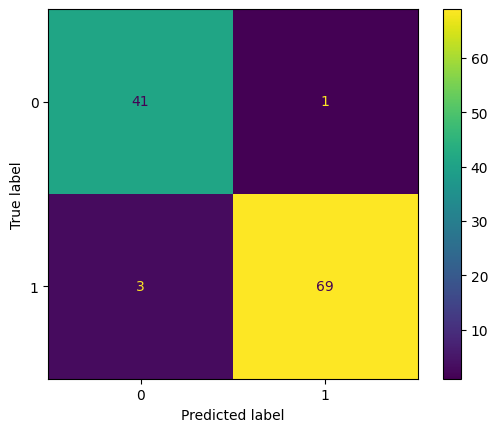

In [357]:
cm = confusion_matrix(
    y_test, 
    y_pred, 
    labels=best_model.classes_
    )

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
    )

disp.plot()
plt.show()

Scores

In [358]:
print('Métricos:')
print(classification_report(y_test, y_pred))
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}, Precision: {precision_score(y_test, y_pred):.4f}, Recall: {recall_score(y_test, y_pred):.4f}, F1-Score: {f1_score(y_test, y_pred):.4f}')

Métricos:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

Accuracy: 0.9649, Precision: 0.9857, Recall: 0.9583, F1-Score: 0.9718
